# SPK Seleksi Penerima Beasiswa KIP-K dengan PROMETHEE II

Notebook ini mengimplementasikan Sistem Pendukung Keputusan (SPK) untuk seleksi beasiswa KIP-K menggunakan metode PROMETHEE II. Proses meliputi pengolahan data mentah, skoring kriteria C1-C6, perhitungan aliran preferensi (Net Flow), hingga validasi hasil terhadap data penetapan aktual.

In [1]:
# --- TAHAP 0 - INSTALL LIBRARY DAN KONFIGURASI -----------------------------

import json
import os
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Path data
DATA_PATH = "data/raw/V_Data_Mahasiswa_Full_KIPK.xlsx"
DITETAPKAN_PATH = "data/raw/Mahasiswa_ditetapkan_Politeknik_Negeri_Jember_20241012.xlsx"
DITETAPKAN_PATH_FALLBACKS = [
    "data/raw/Mahasiswa_ditetapkan_Politeknik Negeri Jember_20241012.xlsx",
]
CLEAN_PATH = "data/processed/data_clean.csv"

# Path output
OUT_RANKING = "output/hasil_ranking.xlsx"
OUT_VALIDASI = "output/validasi_result.json"
OUT_MODEL = "output/model/model_promethee.joblib"
OUT_CONFIG = "output/model/scaler_config.json"
OUT_FIG_DIST = "output/figures/distribusi_kriteria.png"
OUT_FIG_FLOW = "output/figures/promethee_flow.png"
OUT_FIG_CM = "output/figures/confusion_matrix.png"

# Kuota penerima.
# None = gunakan jumlah penerima aktual yang cocok dengan data pendaftar untuk validasi historis.
# Untuk implementasi tahun berjalan, isi dengan kuota resmi institusi, misalnya KUOTA = 437.
KUOTA = None
MIN_IMPLEMENTATION_METRIC = 0.70
CALIBRATION_NOTE = "Bobot dikalibrasi dari data penetapan 2024 setelah perbaikan preprocessing missing value."
TIE_BREAKER_CRITERIA = ["C3", "C5", "C2", "C4", "C1", "C6"]

# Konfigurasi kriteria dan bobot
CRITERIA = {
    "C1": {"name": "Kepemilikan KIP SMA", "weight": 0.04, "type": "benefit"},
    "C2": {"name": "Status DTKS", "weight": 0.17, "type": "benefit"},
    "C3": {"name": "Desil", "weight": 0.49, "type": "benefit"},
    "C4": {"name": "Penghasilan Orang Tua", "weight": 0.03, "type": "benefit"},
    "C5": {"name": "Status Orang Tua", "weight": 0.24, "type": "benefit"},
    "C6": {"name": "Prestasi", "weight": 0.03, "type": "benefit"},
}

# Mapping sub-kriteria teks ke nilai numerik
SUB_CRITERIA_MAP = {
    "C1": {
        "Memiliki KIP": 4,
        "Tidak memiliki KIP, tetapi termasuk keluarga penerima bantuan sosial lain": 3,
        "Tidak memiliki KIP, tetapi memiliki SKTM dari pihak berwenang": 2,
        "Tidak memiliki semuanya": 1,
    },
    "C2": {
        "Terdaftar dalam DTKS": 3,
        "Penerima bantuan sosial": 2,
        "Belum terdaftar": 1,
    },
    "C3": {
        "Desil 1": 4,
        "Desil 2": 3,
        "Desil 3": 2,
        "Desil > 4": 1,
    },
    "C4": {
        "<= Rp 1.000.000": 5,
        "> Rp 1.000.000 s.d. <= Rp 2.000.000": 4,
        "> Rp 2.000.000 s.d. <= Rp 3.000.000": 3,
        "> Rp 3.000.000 s.d. <= Rp 4.000.000": 2,
        "> Rp 4.000.000": 1,
    },
    "C5": {
        "Yatim Piatu": 4,
        "Yatim / Piatu": 3,
        "Orang tua sakit / tidak bekerja": 2,
        "Orang tua masih bekerja": 1,
    },
    "C6": {
        "Internasional": 5,
        "Nasional": 4,
        "Provinsi / Kota": 3,
        "Sekolah": 2,
        "Tidak ada": 1,
    },
}

for folder in ["data/processed", "output/model", "output/figures"]:
    os.makedirs(folder, exist_ok=True)

def normalize_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

def normalize_column_name(value):
    text = normalize_text(value)
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")

def resolve_existing_path(path, fallbacks=None):
    candidates = [path] + list(fallbacks or [])
    for candidate in candidates:
        if Path(candidate).exists():
            return candidate
    raise FileNotFoundError("File tidak ditemukan. Kandidat path: " + ", ".join(candidates))

def find_column(df, candidates=None, contains_any=None, contains_all=None, exclude_any=None):
    candidates = [normalize_column_name(c) for c in (candidates or [])]
    contains_any = [normalize_column_name(c) for c in (contains_any or [])]
    contains_all = [normalize_column_name(c) for c in (contains_all or [])]
    exclude_any = [normalize_column_name(c) for c in (exclude_any or [])]
    normalized = {col: normalize_column_name(col) for col in df.columns}

    for col, norm in normalized.items():
        if norm in candidates:
            return col
    for col, norm in normalized.items():
        if exclude_any and any(token in norm for token in exclude_any):
            continue
        if contains_all and not all(token in norm for token in contains_all):
            continue
        if contains_any and not any(token in norm for token in contains_any):
            continue
        if contains_any or contains_all:
            return col
    return None

def clean_identifier(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True).str.upper()
    return cleaned.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})

def read_label_excel(path):
    df_candidate = pd.read_excel(path)
    if find_column(df_candidate, candidates=["NIM"]):
        return df_candidate
    return pd.read_excel(path, header=1)

def parse_income_to_amount(value):
    text = normalize_text(value)
    if text in {"", "-", "_", "nan", "none"}:
        return np.nan
    if text in {"0", "tidak berpenghasilan"}:
        return 0.0
    numbers = re.findall(r"\d[\d\.]*", text)
    if not numbers:
        return np.nan
    parsed = []
    for number in numbers:
        digits = re.sub(r"[^0-9]", "", number)
        if digits:
            parsed.append(float(digits))
    if not parsed:
        return np.nan
    return max(parsed)

def income_to_score(amount):
    if pd.isna(amount):
        return 1
    if amount <= 1_000_000:
        return 5
    if amount <= 2_000_000:
        return 4
    if amount <= 3_000_000:
        return 3
    if amount <= 4_000_000:
        return 2
    return 1

print("Konfigurasi selesai")

Konfigurasi selesai


In [2]:
# --- TAHAP 1 - LOAD DATA MENTAH --------------------------------------------

try:
    data_path = resolve_existing_path(DATA_PATH)
    ditetapkan_path = resolve_existing_path(DITETAPKAN_PATH, DITETAPKAN_PATH_FALLBACKS)
    df_raw = pd.read_excel(data_path)
    df_label = read_label_excel(ditetapkan_path)
except FileNotFoundError as error:
    print(f"ERROR: {error}")
    raise

print(f"Data pendaftar dibaca dari: {data_path}")
print(f"Shape df_raw: {df_raw.shape}")
print("Kolom df_raw:")
print(list(df_raw.columns))
display(df_raw.head())

print(f"Data ground truth dibaca dari: {ditetapkan_path}")
print(f"Shape df_label: {df_label.shape}")
print("Kolom df_label:")
print(list(df_label.columns))
display(df_label.head())

print("Load data mentah selesai")

Data pendaftar dibaca dari: data/raw/V_Data_Mahasiswa_Full_KIPK.xlsx
Shape df_raw: (1005, 63)
Kolom df_raw:
['no_pendaftaran', 'nim', 'nama', 'program', 'program_studi', 'tgl_lahir', 'tmp_lahir', 'jenis_kelamin', 'warga', 'agama', 'alamat', 'kota', 'kecamatan', 'kelurahan', 'no_telp', 'darah', 'anak_ke', 'nisn', 'nik', 'status_kawin', 'ukuran_baju', 'tinggi', 'berat', 'ayah', 'kerja_ayah', 'penghasilan_ayah', 'keterangan_ayah', 'thlahir_ayah', 'pendidikan_ayah', 'nik_ayah', 'ibu', 'kerja_ibu', 'penghasilan_ibu', 'keterangan_ibu', 'thlahir_ibu', 'pendidikan_ibu', 'nik_ibu', 'alamat_ortu', 'kota_ortu', 'no_telp_ortu', 'jumlah_anak', 'smu', 'jurusan_smu', 'alamat_smu', 'npsn', 'lulussmu', 'nijazah', 'nun', 'prestasi_olahraga', 'pernah_pt', 'pt_asal', 'tahun_masuk_pt', 'jumlah_sks', 'sumber_biaya', 'lembaga', 'jenis_lembaga', 'jenis_tempat_tinggal', 'transportasi', 'minat', 'info_polije', 'dtk', 'desil', 'jalur_seleksi']


,no_pendaftaran,nim,nama,program,program_studi,tgl_lahir,tmp_lahir,jenis_kelamin,warga,agama,...,sumber_biaya,lembaga,jenis_lembaga,jenis_tempat_tinggal,transportasi,minat,info_polije,dtk,desil,jalur_seleksi
0,424208657,B31240613,SEPTI ANGGRAENI,D3,Keteknikan Pertanian,2005-09-10,jember,P,WNI,Islam,...,Ayah,NaN,NaN,Milik Sendiri,sepeda motor,keteknikan pertanian,Sekolah,Ya,Desil 2,SNBP-KIPK
1,424318538,A44240466,MOH RIYAN RISKIADI,D4,Pengelolaan Perkebunan Kopi,2005-03-16,JEMBER,L,WNI,Islam,...,Beasiswa,Prestasi,Swasta,Milik Sendiri,15.000,Minat,Sekolah,Ya,Desil 4,SNBP-KIPK
2,424538144,H41240176,BAGAS DWI CAHYA LASMANA,D4,Teknik Energi Terbarukan,2006-05-06,jember,L,WNI,Islam,...,Ibu,NaN,NaN,Milik Sendiri,sepeda motor,musik,Sekolah,Ya,Desil 5,SNBP-KIPK
3,424599830,C42240403,ADI PUTRA,D4,Teknologi Pakan Ternak,2005-03-18,jember-18-maret-2005,L,WNI,Islam,...,Ayah,NaN,NaN,Kontrak,motor,bola voly,Sekolah,Ya,Desil 5,SNBP-KIPK
4,424549305,I42240034,RAMADHANI,D4,Manajemen Pemasaran Internasional,2004-10-20,Jember,L,WNI,Islam,...,Ayah,NaN,NaN,Milik Sendiri,Sepeda motor,Tidak ada,Media Sosial,Ya,Desil 5,SNBP-KIPK


Data ground truth dibaca dari: data/raw/Mahasiswa_ditetapkan_Politeknik Negeri Jember_20241012.xlsx
Shape df_label: (465, 50)
Kolom df_label:
['#', 'No. Pendaftaran', 'Nama Siswa', 'NIK', 'No. Kartu Keluarga', 'NIK Kepala Keluarga', 'NISN', 'Status DTKS', 'Status P3KE', 'No. KIP', 'No. KKS', 'Asal Sekolah', 'Kab/Kota Sekolah', 'Provinsi Sekolah', 'Tempat Lahir', 'Tanggal Lahir', 'Jenis Kelamin', 'Alamat Tinggal', 'No. Handphone', 'Alamat Email', 'Nama Ayah', 'Pekerjaan Ayah', 'Penghasilan Ayah', 'Status Ayah', 'Nama Ibu', 'Pekerjaan Ibu', 'Penghasilan Ibu', 'Status Ibu', 'Jumlah Tanggungan', 'Kepemilikan Rumah', 'Tahun Perolehan', 'Sumber Listrik', 'Luas Tanah', 'Luas Bangunan', 'Sumber Air', 'MCK', 'Jarak Pusat Kota (KM)', 'Tanggal Ditetapkan', 'User Penetapan', 'Seleksi Penetapan', 'Perguruan Tinggi', 'Program Studi', 'Akreditasi Prodi', 'UKT/SPP', 'Ranking Penetapan', 'NIM', 'Semester', 'Kategori Penetapan', 'Skema Bantuan Pembiayaan', 'Prestasi']


,#,No. Pendaftaran,Nama Siswa,NIK,No. Kartu Keluarga,NIK Kepala Keluarga,NISN,Status DTKS,Status P3KE,No. KIP,...,Perguruan Tinggi,Program Studi,Akreditasi Prodi,UKT/SPP,Ranking Penetapan,NIM,Semester,Kategori Penetapan,Skema Bantuan Pembiayaan,Prestasi
0,1,1124.205.23756.1787.308,Muhammad Asda Balda,3509213110050001,3509211005100119,3509210211650004,57849756,Belum Terdata,Terdata: Desil 7,-,...,Politeknik Negeri Jember,21312 - D4 Teknologi Rekayasa Mekatronika,Baik,Rp2.400.000,1,H43241772,1,Baru,Bantuan Biaya Hidup & Biaya Pendidikan,NaN
1,2,1124.205.25855.1745.120,ZHAFRAN REGAN GALEN PURNOMO,3510151903060001,3510153001190002,3510156206770003,62766129,Belum Terdata,Terdata: Desil 5,-,...,Politeknik Negeri Jember,62303 - D4 Akuntansi Sektor Publik,Baik,Rp2.400.000,1,I41241548,1,Baru,Bantuan Biaya Hidup & Biaya Pendidikan,NaN
2,3,1124.205.49428.1710.922,Ibnu Alaudin Sa'id,3513172808050002,3513171801060161,3513172610710001,53621495,Terdata,Terdata: Desil 3,-,...,Politeknik Negeri Jember,54412 - D3 Produksi Tanaman Hortikultura,A,Rp3.400.000,1,A31240150,1,Baru,Bantuan Biaya Hidup & Biaya Pendidikan,1. Juara 1 - Marchingband 2023 - Tingkat Provinsi
3,4,1124.205.23827.1752.445,THERESIA DONNA AGATHA,3509207010050002,3509203004100010,3509201206740004,59967828,Belum Terdata,Terdata: Desil 2,-,...,Politeknik Negeri Jember,54412 - D3 Produksi Tanaman Hortikultura,A,Rp3.400.000,1,A31240637,1,Baru,Bantuan Biaya Hidup & Biaya Pendidikan,NaN
4,5,1124.205.21725.1799.843,FAISAL ALFIN NURI,3511091606050003,3511091508080014,3511090605760002,55025593,Terdata,Terdata: Desil 1,-,...,Politeknik Negeri Jember,54412 - D3 Produksi Tanaman Hortikultura,A,Rp3.400.000,1,A31241080,1,Baru,Bantuan Biaya Hidup & Biaya Pendidikan,NaN


Load data mentah selesai


In [3]:
# --- TAHAP 2 - PREPROCESSING ------------------------------------------------

def is_empty_like(value):
    text = normalize_text(value)
    return text in {"", "-", "_", "nan", "none", "null"}

def fill_missing_values(df):
    filled = df.copy()
    for col in filled.columns:
        if pd.api.types.is_numeric_dtype(filled[col]):
            median = filled[col].median()
            filled[col] = filled[col].fillna(0 if pd.isna(median) else median)
        else:
            values = filled[col].replace(r"^\s*$", np.nan, regex=True)
            mode = values.dropna().mode()
            replacement = mode.iloc[0] if not mode.empty else "Tidak ada"
            filled[col] = values.fillna(replacement)
    return filled

def score_c1(row, kip_col, jalur_col, fallback_cols):
    texts = []
    if kip_col and kip_col in row.index:
        texts.append(normalize_text(row[kip_col]))
    if jalur_col and jalur_col in row.index:
        texts.append(normalize_text(row[jalur_col]))
    for col in fallback_cols:
        if col and col in row.index:
            texts.append(normalize_text(row[col]))
    text = " ".join(texts)
    # Jika jalur seleksi eksplisit KIPK, beri skor maksimal
    if any(token in text for token in ["kip", "kartu indonesia pintar", "kipk"]):
        return 4
    if any(token in text for token in ["bansos", "bantuan sosial", "kks", "pkh", "beasiswa"]):
        return 3
    if "sktm" in text:
        return 2
    return 1

def score_c2(value):
    text = normalize_text(value)
    if any(token in text for token in ["belum", "tidak", "non dtks", "non-dtks"]):
        return 1
    if any(token in text for token in ["terdaftar", "terdata", "dtks", "ya"]):
        return 3
    if any(token in text for token in ["bansos", "bantuan", "kks", "pkh"]):
        return 2
    return 1

def score_c3(value):
    text = normalize_text(value)
    match = re.search(r"(\d+)", text)
    if not match:
        return 1
    desil = int(match.group(1))
    if desil == 1:
        return 4
    if desil == 2:
        return 3
    if desil == 3:
        return 2
    return 1

def score_c5(row, status_ayah_col, status_ibu_col, kerja_ayah_col, kerja_ibu_col):
    status_ayah = normalize_text(row[status_ayah_col]) if status_ayah_col else ""
    status_ibu = normalize_text(row[status_ibu_col]) if status_ibu_col else ""
    kerja_ayah = normalize_text(row[kerja_ayah_col]) if kerja_ayah_col else ""
    kerja_ibu = normalize_text(row[kerja_ibu_col]) if kerja_ibu_col else ""
    ayah_meninggal = any(token in status_ayah for token in ["meninggal", "wafat"])
    ibu_meninggal = any(token in status_ibu for token in ["meninggal", "wafat"])
    if ayah_meninggal and ibu_meninggal:
        return 4
    if ayah_meninggal or ibu_meninggal:
        return 3
    combined = " ".join([status_ayah, status_ibu, kerja_ayah, kerja_ibu])
    if any(token in combined for token in ["tidak bekerja", "sakit", "disabilitas"]):
        return 2
    return 1

def score_c6(value):
    text = normalize_text(value)
    if text in {"", "-", "_", "0", "tidak ada", "belum ada", "tidak berprestasi", "(-)", "\"-\""}:
        return 1
    if "internasional" in text:
        return 5
    if "nasional" in text:
        return 4
    if any(token in text for token in ["provinsi", "kabupaten", "kota", "kejurda", "kejurb", "bupati", "walikota", "jawa timur"]):
        return 3
    return 2

nim_col = find_column(df_raw, candidates=["nim"], contains_any=["nim"])
nama_col = find_column(df_raw, candidates=["nama"], contains_any=["nama"])
kip_col = find_column(df_raw, contains_any=["kip", "no_kip", "kartu_indonesia_pintar"])
dtks_col = find_column(df_raw, candidates=["dtk", "dtks", "status_dtks"], contains_any=["dtk", "dtks"])
desil_col = find_column(df_raw, candidates=["desil"], contains_any=["desil", "p3ke"])
penghasilan_ayah_col = find_column(df_raw, candidates=["penghasilan_ayah"], contains_all=["penghasilan", "ayah"])
penghasilan_ibu_col = find_column(df_raw, candidates=["penghasilan_ibu"], contains_all=["penghasilan", "ibu"])
status_ayah_col = find_column(df_raw, candidates=["keterangan_ayah", "status_ayah"], contains_any=["keterangan_ayah", "status_ayah"])
status_ibu_col = find_column(df_raw, candidates=["keterangan_ibu", "status_ibu"], contains_any=["keterangan_ibu", "status_ibu"])
kerja_ayah_col = find_column(df_raw, candidates=["kerja_ayah", "pekerjaan_ayah"], contains_any=["kerja_ayah", "pekerjaan_ayah"])
kerja_ibu_col = find_column(df_raw, candidates=["kerja_ibu", "pekerjaan_ibu"], contains_any=["kerja_ibu", "pekerjaan_ibu"])
prestasi_col = find_column(df_raw, candidates=["prestasi_olahraga", "prestasi"], contains_any=["prestasi"])
jalur_seleksi_col = find_column(df_raw, candidates=["jalur_seleksi"], contains_any=["jalur_seleksi"])
fallback_c1_cols = [
    find_column(df_raw, candidates=["lembaga"]),
    find_column(df_raw, candidates=["sumber_biaya"]),
    find_column(df_raw, candidates=["jenis_lembaga"]),
]

required_detected = {
    "NIM": nim_col,
    "Nama": nama_col,
    "C1 Status KIPK": jalur_seleksi_col,
    "C2 Status DTKS": dtks_col,
    "C3 Desil": desil_col,
    "C4 Penghasilan Ayah": penghasilan_ayah_col,
    "C4 Penghasilan Ibu": penghasilan_ibu_col,
    "C5 Status Ayah": status_ayah_col,
    "C5 Status Ibu": status_ibu_col,
    "C6 Prestasi": prestasi_col,
}

missing_required = [name for name, col in required_detected.items() if col is None]
if missing_required:
    raise ValueError("Kolom wajib tidak terdeteksi: " + ", ".join(missing_required))

df_work = df_raw.copy()
df_work[nim_col] = clean_identifier(df_work[nim_col])
duplicate_count = int(df_work.duplicated(subset=[nim_col]).sum())
df_work = df_work.drop_duplicates(subset=[nim_col]).reset_index(drop=True)
missing_before = df_work.isna().sum()

# Kolom kriteria dihitung dari nilai asli. Missing value tidak diisi modus agar
# mahasiswa tidak mendapat skor tinggi hanya karena data kosong.
ayah_amount = df_work[penghasilan_ayah_col].apply(parse_income_to_amount)
ibu_amount = df_work[penghasilan_ibu_col].apply(parse_income_to_amount)
total_penghasilan = ayah_amount.fillna(0) + ibu_amount.fillna(0)
total_penghasilan[ayah_amount.isna() & ibu_amount.isna()] = np.nan

df_clean = pd.DataFrame()
df_clean["NIM"] = clean_identifier(df_work[nim_col])
df_clean["Nama"] = df_work[nama_col].fillna("Tidak ada").astype(str).str.strip()
program_col = find_column(df_work, candidates=["program_studi"], contains_all=["program", "studi"])
if program_col:
    df_clean["Program_Studi"] = df_work[program_col].fillna("Tidak ada")
df_clean["C1"] = df_work.apply(lambda row: score_c1(row, kip_col, jalur_seleksi_col, fallback_c1_cols), axis=1)
df_clean["C2"] = df_work[dtks_col].apply(score_c2)
df_clean["C3"] = df_work[desil_col].apply(score_c3)
df_clean["C4"] = total_penghasilan.apply(income_to_score)
df_clean["C5"] = df_work.apply(lambda row: score_c5(row, status_ayah_col, status_ibu_col, kerja_ayah_col, kerja_ibu_col), axis=1)
df_clean["C6"] = df_work[prestasi_col].apply(score_c6)

for code in CRITERIA:
    df_clean[code] = pd.to_numeric(df_clean[code], errors="coerce").fillna(1).astype(int)

Path(CLEAN_PATH).parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(CLEAN_PATH, index=False)

print("Kolom terdeteksi:")
display(pd.DataFrame([{"Kebutuhan": key, "Kolom": value} for key, value in required_detected.items()]))
if kip_col is None:
    print("Catatan: kolom eksplisit KIP SMA tidak ditemukan. C1 dihitung dari fallback lembaga/sumber_biaya/jenis_lembaga bila tersedia, selain itu bernilai 1.")
print(f"Jumlah duplikat NIM dihapus: {duplicate_count}")
print("Jumlah missing value pada data asli:")
display(missing_before[missing_before > 0].to_frame("missing_count"))
display(df_clean.head())
print(f"Data clean disimpan ke: {CLEAN_PATH}")
print("Preprocessing selesai")

Kolom terdeteksi:


,Kebutuhan,Kolom
0,NIM,nim
1,Nama,nama
2,C1 Status KIPK,jalur_seleksi
3,C2 Status DTKS,dtk
4,C3 Desil,desil
5,C4 Penghasilan Ayah,penghasilan_ayah
6,C4 Penghasilan Ibu,penghasilan_ibu
7,C5 Status Ayah,keterangan_ayah
8,C5 Status Ibu,keterangan_ibu
9,C6 Prestasi,prestasi_olahraga


Catatan: kolom eksplisit KIP SMA tidak ditemukan. C1 dihitung dari fallback lembaga/sumber_biaya/jenis_lembaga bila tersedia, selain itu bernilai 1.
Jumlah duplikat NIM dihapus: 0
Jumlah missing value pada data asli:


,missing_count
keterangan_ayah,9
keterangan_ibu,26
prestasi_olahraga,56
pernah_pt,475
pt_asal,943
tahun_masuk_pt,951
jumlah_sks,954
lembaga,956
jenis_lembaga,949
dtk,4


,NIM,Nama,Program_Studi,C1,C2,C3,C4,C5,C6
0,B31240613,SEPTI ANGGRAENI,Keteknikan Pertanian,4,3,3,5,2,1
1,A44240466,MOH RIYAN RISKIADI,Pengelolaan Perkebunan Kopi,4,3,1,5,1,1
2,H41240176,BAGAS DWI CAHYA LASMANA,Teknik Energi Terbarukan,4,3,1,5,2,1
3,C42240403,ADI PUTRA,Teknologi Pakan Ternak,4,3,1,5,2,1
4,I42240034,RAMADHANI,Manajemen Pemasaran Internasional,4,3,1,5,2,1


Data clean disimpan ke: data/processed/data_clean.csv
Preprocessing selesai


,Kode,Nama,Bobot,Tipe
0,C1,Kepemilikan KIP SMA,0.04,benefit
1,C2,Status DTKS,0.17,benefit
2,C3,Desil,0.49,benefit
3,C4,Penghasilan Orang Tua,0.03,benefit
4,C5,Status Orang Tua,0.24,benefit
5,C6,Prestasi,0.03,benefit


Statistik deskriptif kriteria:


,C1,C2,C3,C4,C5,C6
count,1005.0,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,4.0,2.281592,1.841791,4.235821,1.898507,1.157214
std,0.0,0.960012,1.116628,0.899928,0.586746,0.436347
min,4.0,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.0,1.000000,1.000000,4.000000,2.000000,1.000000
50%,4.0,3.000000,1.000000,4.000000,2.000000,1.000000
75%,4.0,3.000000,3.000000,5.000000,2.000000,1.000000
max,4.0,3.000000,4.000000,5.000000,4.000000,5.000000


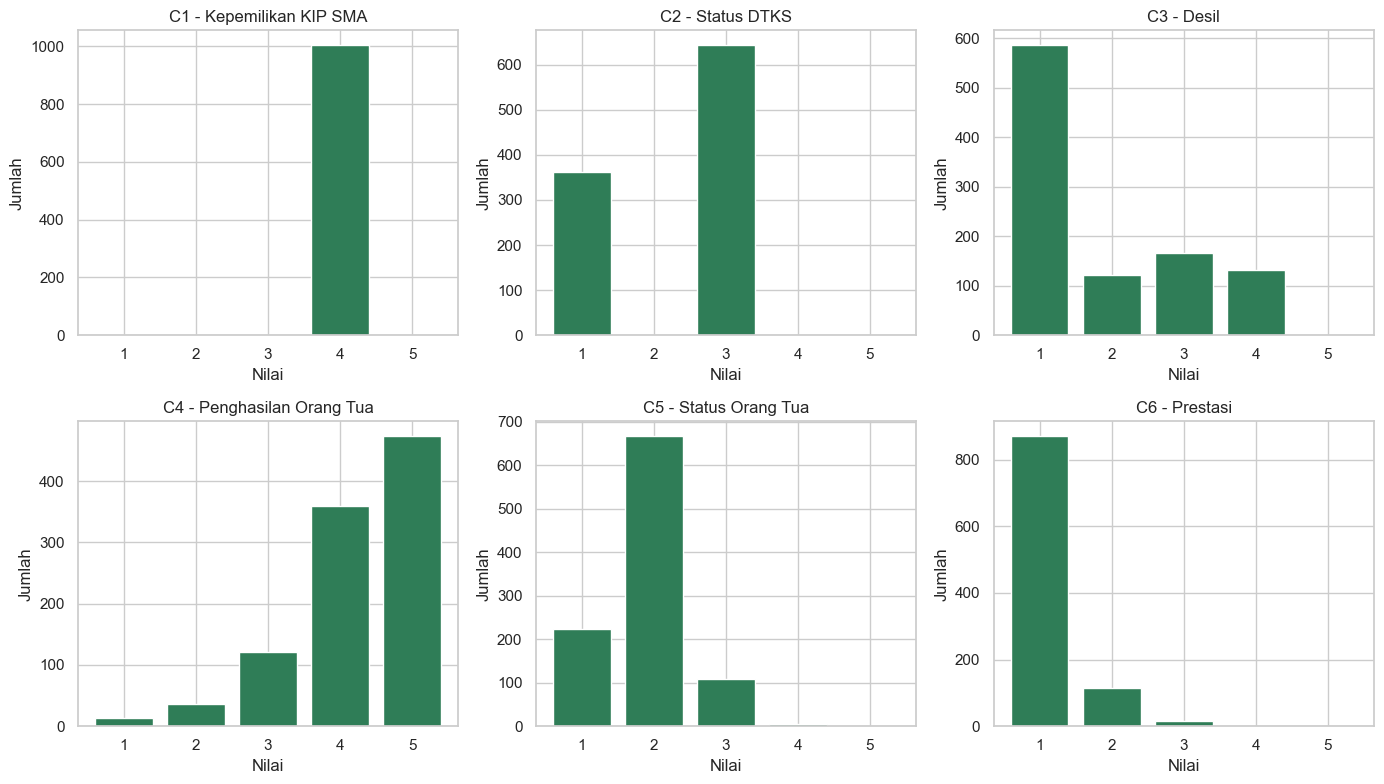

Grafik distribusi disimpan ke: output/figures/distribusi_kriteria.png
Penentuan kriteria dan pembobotan selesai


In [4]:
# --- TAHAP 3 - PENENTUAN KRITERIA DAN PEMBOBOTAN ---------------------------

criteria_codes = list(CRITERIA.keys())
total_weight = sum(item["weight"] for item in CRITERIA.values())
if not np.isclose(total_weight, 1.0):
    raise ValueError(f"Total bobot harus 1.0, saat ini {total_weight}")

criteria_table = pd.DataFrame([
    {"Kode": code, "Nama": cfg["name"], "Bobot": cfg["weight"], "Tipe": cfg["type"]}
    for code, cfg in CRITERIA.items()
])
display(criteria_table)

print("Statistik deskriptif kriteria:")
display(df_clean[criteria_codes].describe())

n_cols = 3
n_rows = int(np.ceil(len(criteria_codes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).ravel()
for idx, code in enumerate(criteria_codes):
    counts = df_clean[code].value_counts().reindex(range(1, 6), fill_value=0)
    axes[idx].bar(counts.index.astype(str), counts.values, color="#2f7d57")
    axes[idx].set_title(f"{code} - {CRITERIA[code]['name']}")
    axes[idx].set_xlabel("Nilai")
    axes[idx].set_ylabel("Jumlah")
for idx in range(len(criteria_codes), len(axes)):
    axes[idx].axis("off")
plt.tight_layout()
Path(OUT_FIG_DIST).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_FIG_DIST, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafik distribusi disimpan ke: {OUT_FIG_DIST}")
print("Penentuan kriteria dan pembobotan selesai")

In [5]:
# --- TAHAP 4 - PERHITUNGAN PROMETHEE II ------------------------------------

class PROMETHEE:
    def __init__(self, weights, criteria, tie_breakers=None):
        self.weights = np.array(weights, dtype=float)
        self.criteria = list(criteria)
        self.tie_breakers = list(tie_breakers or [])

    def preference_function(self, d):
        return 1.0 if d > 0 else 0.0

    def compute_preference_matrix(self, matrix):
        matrix = np.asarray(matrix, dtype=float)
        n = matrix.shape[0]
        pi = np.zeros((n, n), dtype=float)
        for idx, weight in enumerate(self.weights):
            diff = matrix[:, idx, None] - matrix[None, :, idx]
            pi += weight * (diff > 0).astype(float)
        np.fill_diagonal(pi, 0.0)
        return pi

    def leaving_flow(self, pi):
        n = pi.shape[0]
        if n <= 1:
            return np.zeros(n)
        return pi.sum(axis=1) / (n - 1)

    def entering_flow(self, pi):
        n = pi.shape[0]
        if n <= 1:
            return np.zeros(n)
        return pi.sum(axis=0) / (n - 1)

    def net_flow(self, phi_plus, phi_minus):
        return phi_plus - phi_minus

    def sort_rank(self, result):
        sort_columns = ["Net_Flow", "Phi_Plus"]
        sort_ascending = [False, False]
        for column in self.tie_breakers:
            if column in result.columns:
                sort_columns.append(column)
                sort_ascending.append(False)
        for column in ["Nama", "NIM"]:
            if column in result.columns:
                sort_columns.append(column)
                sort_ascending.append(True)
        result = result.sort_values(sort_columns, ascending=sort_ascending).reset_index(drop=True)
        result["Rank"] = np.arange(1, len(result) + 1)
        return result

    def rank(self, decision_matrix):
        result = decision_matrix.copy()
        matrix = result[self.criteria].to_numpy(dtype=float)
        pi = self.compute_preference_matrix(matrix)
        result["Phi_Plus"] = self.leaving_flow(pi)
        result["Phi_Minus"] = self.entering_flow(pi)
        result["Net_Flow"] = self.net_flow(result["Phi_Plus"].to_numpy(), result["Phi_Minus"].to_numpy())
        return self.sort_rank(result), pi

weights = [CRITERIA[code]["weight"] for code in criteria_codes]
promethee = PROMETHEE(weights=weights, criteria=criteria_codes, tie_breakers=TIE_BREAKER_CRITERIA)
df_promethee, pi_matrix = promethee.rank(df_clean)

print("Sudut kiri atas matriks preferensi pi (5x5):")
display(pd.DataFrame(pi_matrix[:5, :5]).round(3))

top_columns = [col for col in ["NIM", "Nama", "Phi_Plus", "Phi_Minus", "Net_Flow"] if col in df_promethee.columns]
display(df_promethee[top_columns].head(10))
print("Perhitungan PROMETHEE II selesai")

Sudut kiri atas matriks preferensi pi (5x5):


,0,1,2,3,4
0,0.0,0.73,0.49,0.49,0.49
1,0.0,0.00,0.00,0.00,0.00
2,0.0,0.24,0.00,0.00,0.00
3,0.0,0.24,0.00,0.00,0.00
4,0.0,0.24,0.00,0.00,0.00


,NIM,Nama,Phi_Plus,Phi_Minus,Net_Flow
0,E31240304,AHMAD HUSNI,0.716295,0.005438,0.710857
1,E32240216,AISYAH NOVITASARI,0.716295,0.005438,0.710857
2,A31241408,ANGGITA LEONI PUTRI,0.716295,0.005438,0.710857
3,G41241431,FENY DWI SETYAWATI,0.716295,0.005438,0.710857
4,E31240337,IMROATUL AZIZAH,0.716295,0.005438,0.710857
5,D31240462,MIA AYU KUSUMA WARDANI,0.716295,0.005438,0.710857
6,I42240770,NOVI DWI LISTYANTI,0.716295,0.005438,0.710857
7,G41240533,RADIKE GINDA AYDILLIA,0.716295,0.005438,0.710857
8,B41241582,WANDA AULIA,0.716295,0.005438,0.710857
9,B41241141,ABDUL AZIS,0.705568,0.019602,0.685966


Perhitungan PROMETHEE II selesai


Peringkat seluruh mahasiswa:


,NIM,Nama,Program_Studi,C1,C2,C3,C4,C5,C6,Phi_Plus,Phi_Minus,Net_Flow,Rank,Layak,Status_Rekomendasi
0,E31240304,AHMAD HUSNI,Manajemen Infomatika,4,3,4,5,3,1,0.716295,0.005438,0.710857,1,True,Direkomendasikan
1,E32240216,AISYAH NOVITASARI,Teknik Komputer,4,3,4,5,3,1,0.716295,0.005438,0.710857,2,True,Direkomendasikan
2,A31241408,ANGGITA LEONI PUTRI,Produksi Tanaman Hortikultura,4,3,4,5,3,1,0.716295,0.005438,0.710857,3,True,Direkomendasikan
3,G41241431,FENY DWI SETYAWATI,Manajemen Informasi Kesehatan PSDKU Ngawi,4,3,4,5,3,1,0.716295,0.005438,0.710857,4,True,Direkomendasikan
4,E31240337,IMROATUL AZIZAH,Manajemen Infomatika,4,3,4,5,3,1,0.716295,0.005438,0.710857,5,True,Direkomendasikan
5,D31240462,MIA AYU KUSUMA WARDANI,Manajemen Agribisnis,4,3,4,5,3,1,0.716295,0.005438,0.710857,6,True,Direkomendasikan
6,I42240770,NOVI DWI LISTYANTI,Manajemen Pemasaran Internasional,4,3,4,5,3,1,0.716295,0.005438,0.710857,7,True,Direkomendasikan
7,G41240533,RADIKE GINDA AYDILLIA,Manajemen Informasi Kesehatan,4,3,4,5,3,1,0.716295,0.005438,0.710857,8,True,Direkomendasikan
8,B41241582,WANDA AULIA,Teknologi Rekayasa Pangan,4,3,4,5,3,1,0.716295,0.005438,0.710857,9,True,Direkomendasikan
9,B41241141,ABDUL AZIS,Teknologi Rekayasa Pangan,4,3,4,4,3,1,0.705568,0.019602,0.685966,10,True,Direkomendasikan


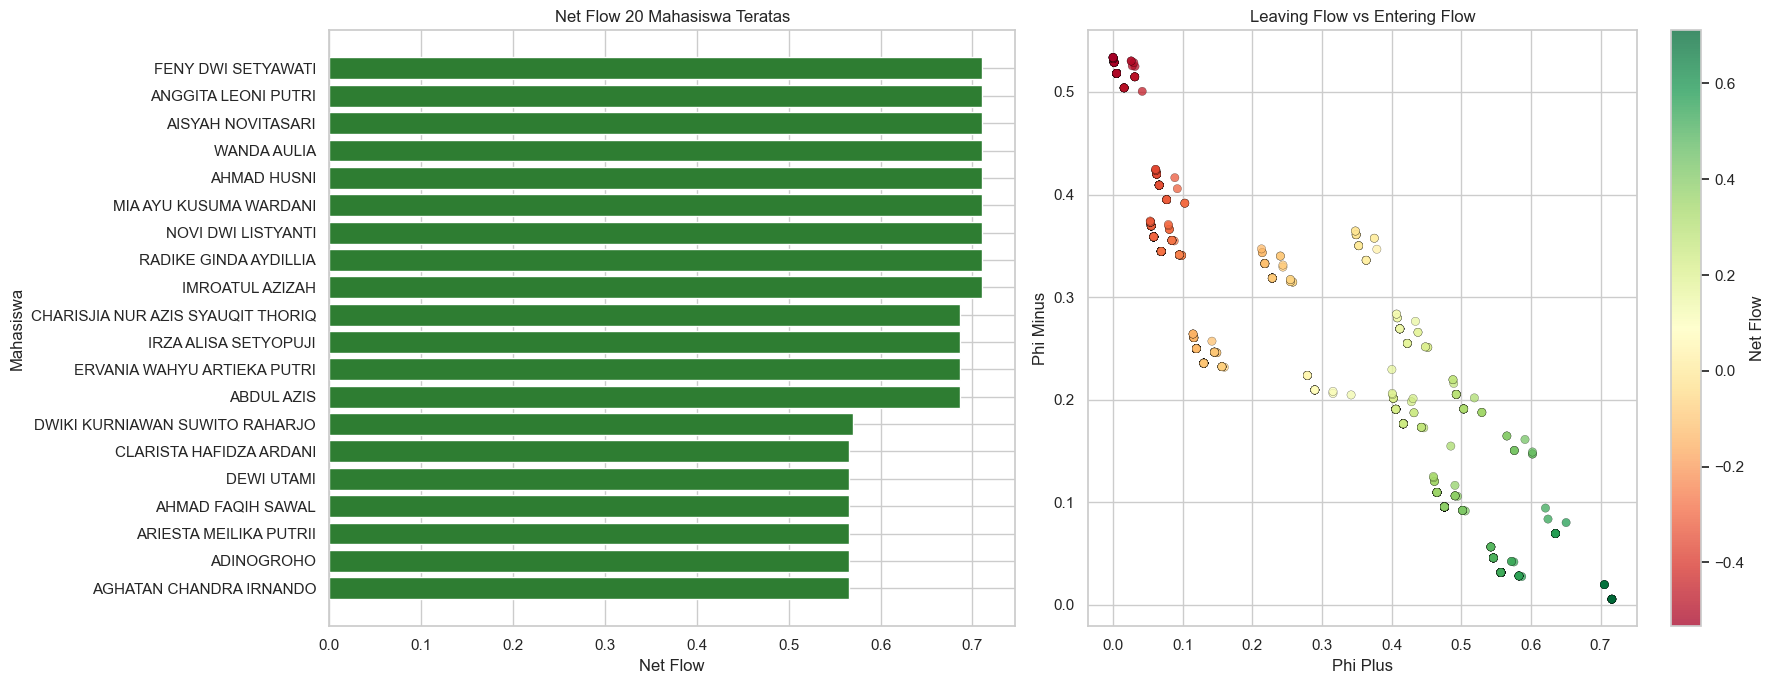

Hasil ranking disimpan ke: output/hasil_ranking.xlsx
Grafik flow disimpan ke: output/figures/promethee_flow.png
Kuota aktif: 437 (ground_truth_matched)
Ranking hasil selesai


In [6]:
# --- TAHAP 5 - RANKING HASIL ------------------------------------------------

label_nim_col_for_quota = find_column(df_label, candidates=["NIM"], contains_any=["nim"])
result_nims = set(clean_identifier(df_promethee["NIM"]))
label_nims_for_quota = set()
matched_label_nims_for_quota = set()
if label_nim_col_for_quota is not None:
    label_nims_for_quota = set(clean_identifier(df_label[label_nim_col_for_quota]).dropna())
    matched_label_nims_for_quota = label_nims_for_quota & result_nims

if KUOTA is None:
    kuota_aktif = len(matched_label_nims_for_quota)
    kuota_source = "ground_truth_matched"
else:
    kuota_aktif = int(KUOTA)
    kuota_source = "manual"

if kuota_aktif <= 0:
    raise ValueError("Kuota aktif tidak valid. Isi KUOTA manual atau pastikan data ground truth cocok dengan data pendaftar.")
if kuota_aktif > len(df_promethee):
    raise ValueError(f"Kuota aktif ({kuota_aktif}) lebih besar dari jumlah data ({len(df_promethee)})")

df_result = promethee.sort_rank(df_promethee)
df_result["Layak"] = df_result["Rank"] <= kuota_aktif
df_result["Status_Rekomendasi"] = np.where(df_result["Layak"], "Direkomendasikan", "Tidak Direkomendasikan")

Path(OUT_RANKING).parent.mkdir(parents=True, exist_ok=True)
df_result.to_excel(OUT_RANKING, index=False)

print("Peringkat seluruh mahasiswa:")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(df_result)

top20 = df_result.head(20).sort_values("Net_Flow", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = np.where(top20["Net_Flow"] >= 0, "#2e7d32", "#c62828")
axes[0].barh(top20["Nama"], top20["Net_Flow"], color=colors)
axes[0].set_title("Net Flow 20 Mahasiswa Teratas")
axes[0].set_xlabel("Net Flow")
axes[0].set_ylabel("Mahasiswa")

scatter = axes[1].scatter(
    df_result["Phi_Plus"],
    df_result["Phi_Minus"],
    c=df_result["Net_Flow"],
    cmap="RdYlGn",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.2,
)
axes[1].set_title("Leaving Flow vs Entering Flow")
axes[1].set_xlabel("Phi Plus")
axes[1].set_ylabel("Phi Minus")
fig.colorbar(scatter, ax=axes[1], label="Net Flow")
plt.tight_layout()
Path(OUT_FIG_FLOW).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_FIG_FLOW, dpi=150, bbox_inches="tight")
plt.show()

print(f"Hasil ranking disimpan ke: {OUT_RANKING}")
print(f"Grafik flow disimpan ke: {OUT_FIG_FLOW}")
print(f"Kuota aktif: {kuota_aktif} ({kuota_source})")
print("Ranking hasil selesai")

Jumlah data evaluasi       : 1005
Kuota aktif               : 437 (ground_truth_matched)
Label ground truth cocok  : 437 dari 465
Accuracy  : 0.7632
Precision : 0.7277
Recall    : 0.7277
F1-Score  : 0.7277
ROC-AUC   : 0.8090
Avg Prec  : 0.7297
Mixed criteria profiles : 47
Minimum error teoritis  : 220


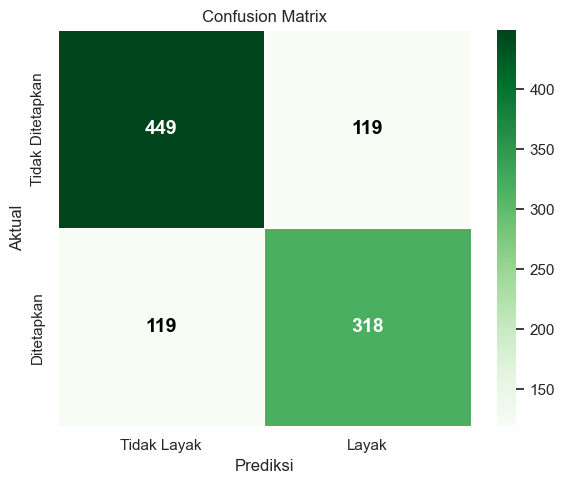

Gambar confusion matrix disimpan ke: output/figures/confusion_matrix.png
Classification Report:
                  precision    recall  f1-score   support

Tidak Ditetapkan       0.79      0.79      0.79       568
      Ditetapkan       0.73      0.73      0.73       437

        accuracy                           0.76      1005
       macro avg       0.76      0.76      0.76      1005
    weighted avg       0.76      0.76      0.76      1005

Model LAYAK diimplementasikan (accuracy, precision, recall, dan F1 >= target minimum)
Validasi model selesai


In [7]:
# --- TAHAP 6 - VALIDASI MODEL ----------------------------------------------

label_nim_col = find_column(df_label, candidates=["NIM"], contains_any=["nim"])
if label_nim_col is None:
    raise ValueError("Kolom NIM pada data ground truth tidak ditemukan")

label_nims = set(clean_identifier(df_label[label_nim_col]).dropna())
df_eval = df_result.copy()
result_nims = set(clean_identifier(df_eval["NIM"]))
matched_label_nims = label_nims & result_nims
unmatched_label_nims = label_nims - result_nims
df_eval["y_true"] = df_eval["NIM"].isin(label_nims).astype(int)
df_eval["y_pred"] = df_eval["Layak"].astype(int)

accuracy = accuracy_score(df_eval["y_true"], df_eval["y_pred"])
precision = precision_score(df_eval["y_true"], df_eval["y_pred"], zero_division=0)
recall = recall_score(df_eval["y_true"], df_eval["y_pred"], zero_division=0)
f1 = f1_score(df_eval["y_true"], df_eval["y_pred"], zero_division=0)
roc_auc = roc_auc_score(df_eval["y_true"], df_eval["Net_Flow"]) if df_eval["y_true"].nunique() == 2 else np.nan
average_precision = average_precision_score(df_eval["y_true"], df_eval["Net_Flow"]) if df_eval["y_true"].nunique() == 2 else np.nan
cm = confusion_matrix(df_eval["y_true"], df_eval["y_pred"], labels=[0, 1])

implementation_minimums = {
    "accuracy": MIN_IMPLEMENTATION_METRIC,
    "precision": MIN_IMPLEMENTATION_METRIC,
    "recall": MIN_IMPLEMENTATION_METRIC,
    "f1_score": MIN_IMPLEMENTATION_METRIC,
}
metric_values = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
}
profile_columns = [code for code in criteria_codes if code in df_eval.columns]
profile_summary = df_eval.groupby(profile_columns).agg(n=("NIM", "size"), positives=("y_true", "sum")).reset_index()
mixed_profiles = profile_summary[(profile_summary["positives"] > 0) & (profile_summary["positives"] < profile_summary["n"])]
minimum_profile_errors = int(np.minimum(mixed_profiles["positives"], mixed_profiles["n"] - mixed_profiles["positives"]).sum())
layak_implementasi = all(metric_values[name] >= minimum for name, minimum in implementation_minimums.items())

validation_result = {
    "jumlah_data": int(len(df_eval)),
    "kuota_aktif": int(kuota_aktif),
    "kuota_source": kuota_source,
    "jumlah_label_ground_truth": int(len(label_nims)),
    "jumlah_label_cocok_dengan_data": int(len(matched_label_nims)),
    "jumlah_label_tidak_cocok_dengan_data": int(len(unmatched_label_nims)),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": None if pd.isna(roc_auc) else float(roc_auc),
    "average_precision": None if pd.isna(average_precision) else float(average_precision),
    "confusion_matrix": cm.astype(int).tolist(),
    "mixed_criteria_profiles": int(len(mixed_profiles)),
    "minimum_errors_if_only_current_criteria": minimum_profile_errors,
    "implementation_minimums": implementation_minimums,
    "layak_implementasi": bool(layak_implementasi),
}

print(f"Jumlah data evaluasi       : {len(df_eval)}")
print(f"Kuota aktif               : {kuota_aktif} ({kuota_source})")
print(f"Label ground truth cocok  : {len(matched_label_nims)} dari {len(label_nims)}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"Avg Prec  : {average_precision:.4f}")
print(f"Mixed criteria profiles : {len(mixed_profiles)}")
print(f"Minimum error teoritis  : {minimum_profile_errors}")

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Greens",
    xticklabels=["Tidak Layak", "Layak"],
    yticklabels=["Tidak Ditetapkan", "Ditetapkan"],
    linewidths=0.5,
    linecolor="white",
)
threshold = cm.max() / 2
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        value = cm[row, col]
        text_color = "white" if value > threshold else "black"
        ax.text(col + 0.5, row + 0.5, f"{value:d}", ha="center", va="center", color=text_color, fontsize=14, fontweight="bold")
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
Path(OUT_FIG_CM).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_FIG_CM, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gambar confusion matrix disimpan ke: {OUT_FIG_CM}")

print("Classification Report:")
print(classification_report(df_eval["y_true"], df_eval["y_pred"], target_names=["Tidak Ditetapkan", "Ditetapkan"], zero_division=0))

if layak_implementasi:
    print("Model LAYAK diimplementasikan (accuracy, precision, recall, dan F1 >= target minimum)")
else:
    print("Model BELUM layak - tinjau ulang bobot, preprocessing, atau nilai KUOTA")

print("Validasi model selesai")

In [8]:
# --- TAHAP 7 - EXPORT MODEL DAN HASIL --------------------------------------

for folder in ["data/processed", "output/model", "output/figures"]:
    os.makedirs(folder, exist_ok=True)

model_package = {
    "model_type": "PROMETHEE_II",
    "criteria_codes": criteria_codes,
    "weights": {code: CRITERIA[code]["weight"] for code in criteria_codes},
    "criteria": CRITERIA,
    "tie_breaker_criteria": TIE_BREAKER_CRITERIA,
    "quota": KUOTA,
    "quota_active": int(kuota_aktif),
    "quota_source": kuota_source,
    "minimum_implementation_metric": MIN_IMPLEMENTATION_METRIC,
    "calibration_note": CALIBRATION_NOTE,
}
joblib.dump(model_package, OUT_MODEL)

config = {
    "criteria": CRITERIA,
    "sub_criteria_map": SUB_CRITERIA_MAP,
    "quota": KUOTA,
    "quota_active": int(kuota_aktif),
    "quota_source": kuota_source,
    "tie_breaker_criteria": TIE_BREAKER_CRITERIA,
    "minimum_implementation_metric": MIN_IMPLEMENTATION_METRIC,
    "calibration_note": CALIBRATION_NOTE,
}
with open(OUT_CONFIG, "w", encoding="utf-8") as file:
    json.dump(config, file, indent=2, ensure_ascii=False)

df_result.to_excel(OUT_RANKING, index=False)

with open(OUT_VALIDASI, "w", encoding="utf-8") as file:
    json.dump(validation_result, file, indent=2, ensure_ascii=False)

for path in [OUT_MODEL, OUT_CONFIG, OUT_RANKING, OUT_VALIDASI, CLEAN_PATH, OUT_FIG_DIST, OUT_FIG_FLOW, OUT_FIG_CM]:
    print(f"Berhasil disimpan: {Path(path).resolve()}")

print("Export model dan hasil selesai")

Berhasil disimpan: D:\spk-kip\output\model\model_promethee.joblib
Berhasil disimpan: D:\spk-kip\output\model\scaler_config.json
Berhasil disimpan: D:\spk-kip\output\hasil_ranking.xlsx
Berhasil disimpan: D:\spk-kip\output\validasi_result.json
Berhasil disimpan: D:\spk-kip\data\processed\data_clean.csv
Berhasil disimpan: D:\spk-kip\output\figures\distribusi_kriteria.png
Berhasil disimpan: D:\spk-kip\output\figures\promethee_flow.png
Berhasil disimpan: D:\spk-kip\output\figures\confusion_matrix.png
Export model dan hasil selesai
